In [35]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Reading Data

In [36]:
df=pd.read_csv("../Datasets/air_traffic_data.csv")
df

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


# Data Preparation

### Checking Data types

In [37]:
df.dtypes

Activity Period                 int64
Operating Airline              object
Operating Airline IATA Code    object
Published Airline              object
Published Airline IATA Code    object
GEO Summary                    object
GEO Region                     object
Activity Type Code             object
Price Category Code            object
Terminal                       object
Boarding Area                  object
Passenger Count                 int64
Adjusted Activity Type Code    object
Adjusted Passenger Count        int64
Year                            int64
Month                          object
dtype: object

### Finding Null values

In [38]:
df.isnull().sum()

Activity Period                 0
Operating Airline               0
Operating Airline IATA Code    54
Published Airline               0
Published Airline IATA Code    54
GEO Summary                     0
GEO Region                      0
Activity Type Code              0
Price Category Code             0
Terminal                        0
Boarding Area                   0
Passenger Count                 0
Adjusted Activity Type Code     0
Adjusted Passenger Count        0
Year                            0
Month                           0
dtype: int64

### Checking uniques values

In [39]:
df["Operating Airline IATA Code"].unique()

array(['TZ', 'AC', 'CA', 'AF', 'NZ', 'FL', 'AS', 'NH', 'AA', 'MQ', 'OZ',
       'EV', '4T', 'BA', 'CX', 'CI', 'DL', 'BR', 'F9', 'HA', 'QX', 'FI',
       'DH', 'JL', 'KL', 'KE', 'LH', 'YV', 'MX', 'YX', 'NW', 'PR', 'SQ',
       'OO', 'SY', 'TA', 'US ', 'UA', 'VS', 'WS', nan, 'GL', 'QK', 'QF',
       'A8', 'NK', 'XP', 'EZ', 'AM', 'B6', 'XE', 'WN', 'VX', 'EI', 'G4',
       '9W', 'BBB', 'EK', 'XJ', 'WO', 'AB', 'RW', 'LX', 'LP', 'SE', 'MU',
       'SK', '5Y', 'CP', 'EY', 'CZ', 'TK', 'CM', 'AI'], dtype=object)

In [40]:
df["Published Airline IATA Code"].unique()

array(['TZ', 'AC', 'CA', 'AF', 'NZ', 'FL', 'AS', 'NH', 'AA', 'OZ', 'DL',
       '4T', 'BA', 'CX', 'CI', 'BR', 'F9', 'HA', 'FI', 'DH', 'JL', 'KL',
       'KE', 'LH', 'US ', 'MX', 'YX', 'NW', 'PR', 'SQ', 'UA', 'SY', 'TA',
       'VS', 'WS', nan, 'GL', 'QF', 'A8', 'NK', 'XP', 'EZ', 'AM', 'B6',
       'WN', 'VX', 'EI', 'G4', '9W', 'BBB', 'EK', 'WO', 'AB', 'RW', 'LX',
       'LP', 'SE', 'MU', 'SK', '5Y', 'EY', 'CZ', 'TK', 'CM', 'AI'],
      dtype=object)

### Replacing white space with underscore in column names

In [41]:
df.columns=df.columns.str.replace(' ','_')

In [42]:
df

,Activity_Period,Operating_Airline,Operating_Airline_IATA_Code,Published_Airline,Published_Airline_IATA_Code,GEO_Summary,GEO_Region,Activity_Type_Code,Price_Category_Code,Terminal,Boarding_Area,Passenger_Count,Adjusted_Activity_Type_Code,Adjusted_Passenger_Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


### Filling Null values

In [43]:
df["Operating_Airline_IATA_Code"]=df["Operating_Airline_IATA_Code"].fillna('Unknown')

In [44]:
df["Published_Airline_IATA_Code"]=df["Published_Airline_IATA_Code"].fillna('Unknown')

### Checking for unique data

In [45]:
df["Operating_Airline"].unique()

array(['ATA Airlines', 'Air Canada ', 'Air China', 'Air France',
       'Air New Zealand', 'AirTran Airways', 'Alaska Airlines',
       'All Nippon Airways', 'American Airlines',
       'American Eagle Airlines', 'Asiana Airlines',
       'Atlantic Southeast Airlines', 'BelAir Airlines',
       'British Airways', 'Cathay Pacific', 'China Airlines',
       'Delta Air Lines', 'EVA Airways', 'Frontier Airlines',
       'Hawaiian Airlines', 'Horizon Air ', 'Icelandair',
       'Independence Air', 'Japan Airlines', 'KLM Royal Dutch Airlines',
       'Korean Air Lines', 'Lufthansa German Airlines', 'Mesa Airlines',
       'Mexicana Airlines', 'Midwest Airlines', 'Northwest Airlines',
       'Philippine Airlines', 'Singapore Airlines', 'SkyWest Airlines',
       'Sun Country Airlines', 'TACA', 'US Airways', 'United Airlines',
       'United Airlines - Pre 07/01/2013', 'Virgin Atlantic',
       'WestJet Airlines', 'Boeing Company', 'Miami Air International',
       'Air Canada Jazz', 'Qantas A

### Replacing the unique data

In [46]:
df["Operating_Airline"]=df["Operating_Airline"].str.replace('United Airlines - Pre 07/01/2013','United Airlines')
df

,Activity_Period,Operating_Airline,Operating_Airline_IATA_Code,Published_Airline,Published_Airline_IATA_Code,GEO_Summary,GEO_Region,Activity_Type_Code,Price_Category_Code,Terminal,Boarding_Area,Passenger_Count,Adjusted_Activity_Type_Code,Adjusted_Passenger_Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


In [47]:
df['Published_Airline'].unique()

array(['ATA Airlines', 'Air Canada ', 'Air China', 'Air France',
       'Air New Zealand', 'AirTran Airways', 'Alaska Airlines',
       'All Nippon Airways', 'American Airlines', 'Asiana Airlines',
       'Delta Air Lines', 'BelAir Airlines', 'British Airways',
       'Cathay Pacific', 'China Airlines', 'EVA Airways',
       'Frontier Airlines', 'Hawaiian Airlines', 'Icelandair',
       'Independence Air', 'Japan Airlines', 'KLM Royal Dutch Airlines',
       'Korean Air Lines', 'Lufthansa German Airlines', 'US Airways',
       'Mexicana Airlines', 'Midwest Airlines', 'Northwest Airlines',
       'Philippine Airlines', 'Singapore Airlines',
       'United Airlines - Pre 07/01/2013', 'Sun Country Airlines', 'TACA',
       'United Airlines', 'Virgin Atlantic', 'WestJet Airlines',
       'Boeing Company', 'Miami Air International', 'Qantas Airways',
       'Ameriflight', 'Spirit Airlines', 'Xtra Airways',
       'Evergreen International Airlines', 'Aeromexico',
       'JetBlue Airways ', '

In [48]:
df['Published_Airline']=df['Published_Airline'].str.replace('United Airlines - Pre 07/01/2013','United Airlines')
df

,Activity_Period,Operating_Airline,Operating_Airline_IATA_Code,Published_Airline,Published_Airline_IATA_Code,GEO_Summary,GEO_Region,Activity_Type_Code,Price_Category_Code,Terminal,Boarding_Area,Passenger_Count,Adjusted_Activity_Type_Code,Adjusted_Passenger_Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


### Changing the format of Activity Period column

In [49]:
df.Activity_Period=pd.to_datetime(df.Activity_Period,format='%Y%m')
df

,Activity_Period,Operating_Airline,Operating_Airline_IATA_Code,Published_Airline,Published_Airline_IATA_Code,GEO_Summary,GEO_Region,Activity_Type_Code,Price_Category_Code,Terminal,Boarding_Area,Passenger_Count,Adjusted_Activity_Type_Code,Adjusted_Passenger_Count,Year,Month
0,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,2005-07-01,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,2005-07-01,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,2016-03-01,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,2016-03-01,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,2016-03-01,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,2016-03-01,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


In [50]:
df.GEO_Region.unique()

array(['US', 'Canada', 'Asia', 'Europe', 'Australia / Oceania', 'Mexico',
       'Central America', 'Middle East', 'South America'], dtype=object)

In [51]:
df.GEO_Region=df.GEO_Region.str.replace('Australia / Oceania','Oceania')
df

,Activity_Period,Operating_Airline,Operating_Airline_IATA_Code,Published_Airline,Published_Airline_IATA_Code,GEO_Summary,GEO_Region,Activity_Type_Code,Price_Category_Code,Terminal,Boarding_Area,Passenger_Count,Adjusted_Activity_Type_Code,Adjusted_Passenger_Count,Year,Month
0,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,2005-07-01,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,2005-07-01,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,2016-03-01,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,2016-03-01,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,2016-03-01,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,2016-03-01,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


# Exploratory Data Analysis (EDA):

In [52]:
df.describe()

,Activity_Period,Passenger_Count,Adjusted_Passenger_Count,Year
count,15007,15007.000000,15007.000000,15007.000000
mean,2010-11-05 19:37:51.020190464,29240.521090,29331.917105,2010.385220
min,2005-07-01 00:00:00,1.000000,1.000000,2005.000000
25%,2008-03-01 00:00:00,5373.500000,5495.500000,2008.000000
50%,2010-11-01 00:00:00,9210.000000,9354.000000,2010.000000
75%,2013-08-01 00:00:00,21158.500000,21182.000000,2013.000000
max,2016-03-01 00:00:00,659837.000000,659837.000000,2016.000000
std,NaN,58319.509284,58284.182219,3.137589


### Distribution of Passengers in every Operating Airline

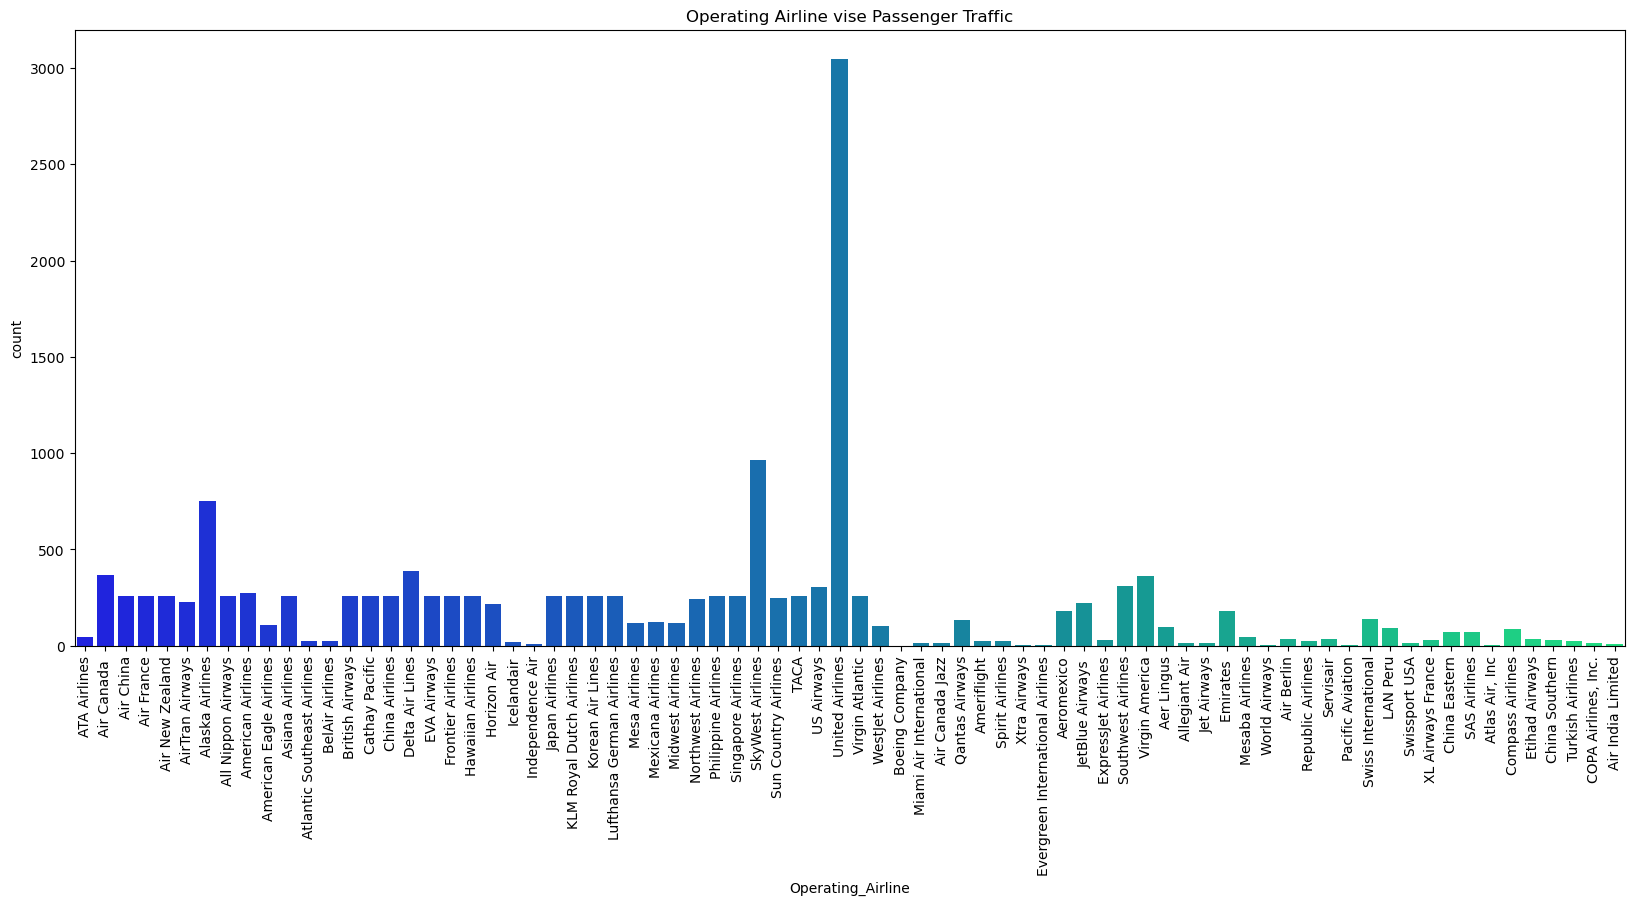

In [53]:
plt.figure(figsize=(20,8))
sb.countplot(x=df.Operating_Airline,palette='winter')
plt.title("Operating Airline vise Passenger Traffic")
plt.xticks(rotation=90)
plt.show()

# Passenger Distribution:-
#### -Maximun passenger traffic is diverted towards United Airlines.

## Count of passengers according to GEO-Region 

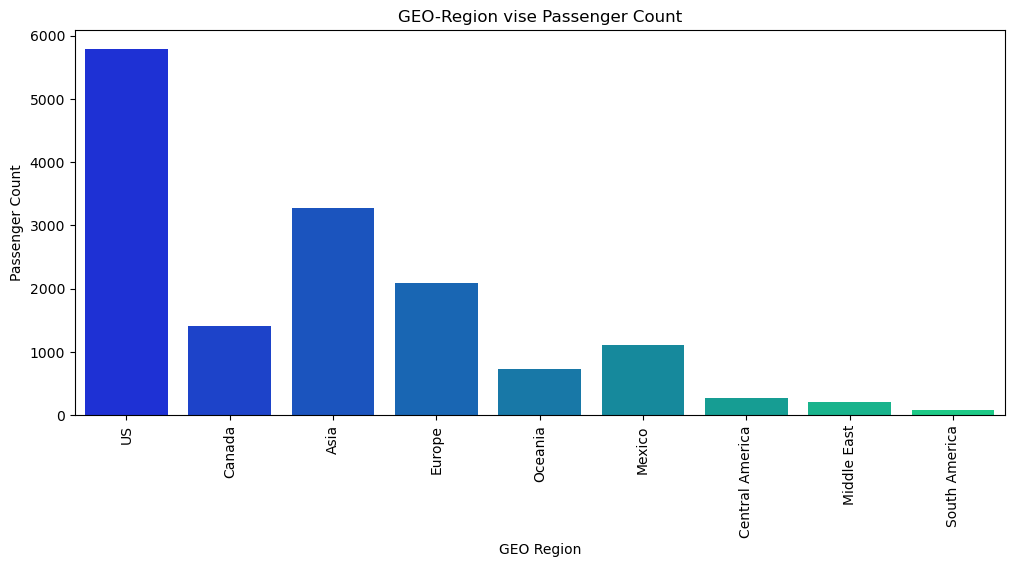

In [54]:
plt.figure(figsize=(12,5))
sb.countplot(x=df.GEO_Region,palette='winter')
plt.title("GEO-Region vise Passenger Count")
plt.xlabel("GEO Region")
plt.ylabel("Passenger Count")
plt.xticks(rotation=90)
plt.show()

# Region Status:-
#### -Most rushed region is US and then comes Asia.
#### -While least rushed were Central and South America with Middle East region too.

## Count of passengers according to GEO-Summary

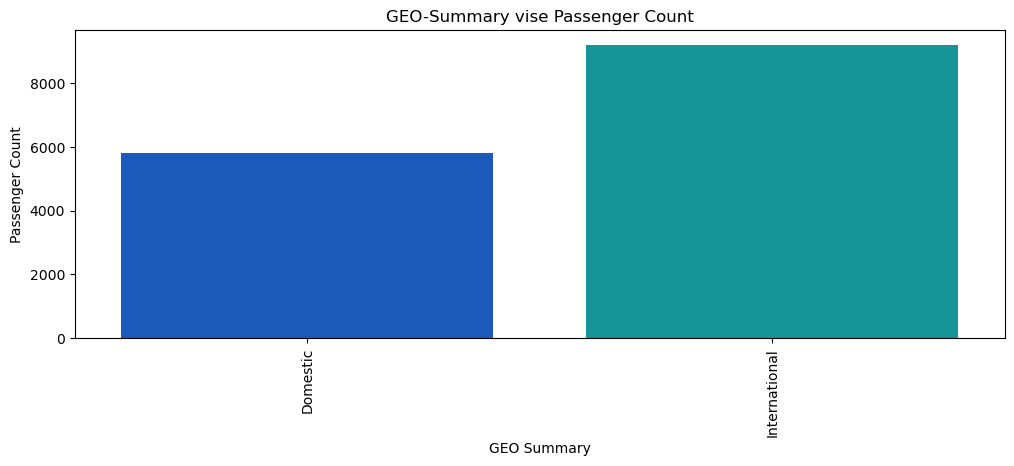

In [55]:
plt.figure(figsize=(12,4))
sb.countplot(x=df.GEO_Summary,palette='winter')
plt.title("GEO-Summary vise Passenger Count")
plt.xlabel("GEO Summary")
plt.ylabel("Passenger Count")
plt.xticks(rotation=90)
plt.show()

# Airline Services:-
#### -Most of the passenger were travelling under International Flights.
#### -More than half count was of Domestic Flights.

## Regions having highest passenger traffic

In [56]:
r=df.groupby('GEO_Region')['Passenger_Count'].sum().nlargest(5)
r

GEO_Region
US        338141001
Asia       43972770
Europe     26646558
Canada     13865159
Mexico      7998587
Name: Passenger_Count, dtype: int64

# Highest Traffic:-
#### -Highest passenger traffic is in US Region and decreases as it comes to Asia and Europe.

## Regions having lowest passenger traffic

In [57]:
s=df.groupby('GEO_Region')['Passenger_Count'].sum().nsmallest(5)
s

GEO_Region
South America       250741
Central America    1355400
Middle East        1852943
Oceania            4729341
Mexico             7998587
Name: Passenger_Count, dtype: int64

# Lowest Traffic:-
#### -Lowest passenger traffic is in South America Region and from there it increases for Central America and Middle East Region.

## Combine graph of highest and lowest passenger count

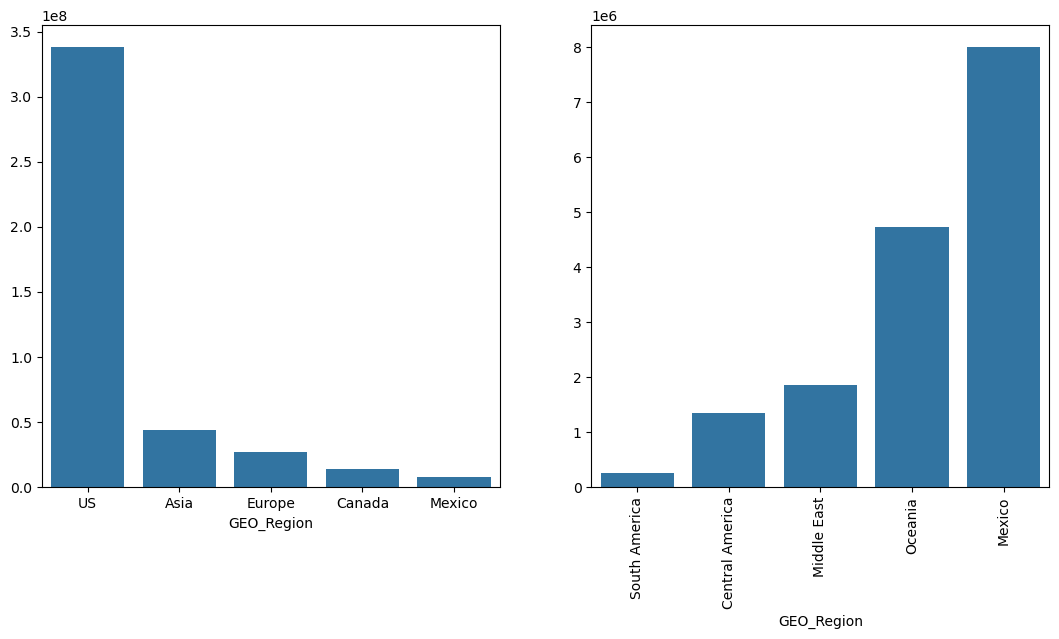

In [58]:
plt.figure(figsize=(13,6))

plt.subplot(121)
sb.barplot(x=r.index,y=r.values)

plt.subplot(122)
sb.barplot(x=s.index,y=s.values)
plt.xticks(rotation=90)

plt.show()

# Passenger Traffic:-
#### -US is having most of the passenger traffic whereas South America have least passenger traffic.
#### -Count of other regions is between both these regions.

## Different activity types contributing to passenger counts

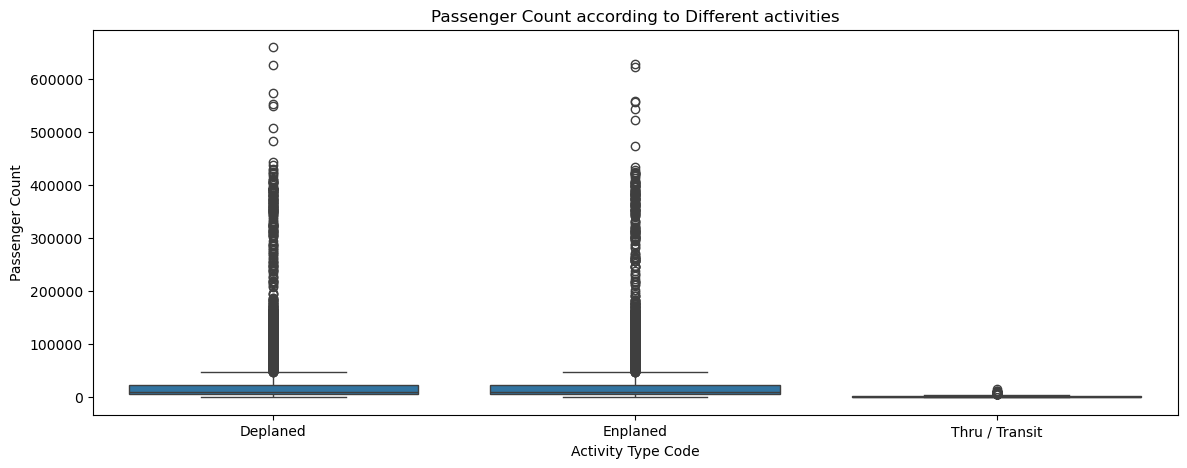

In [59]:
plt.figure(figsize=(14,5))
sb.boxplot(x=df.Activity_Type_Code,y=df.Passenger_Count)
plt.title("Passenger Count according to Different activities")
plt.xlabel("Activity Type Code")
plt.ylabel("Passenger Count")
plt.show()

# Passenger activities:-
#### -Most of the passenger were busy in Boarding and Deboarding plane.
#### -Very few number of passengers were there in Transit waiting for the connecting flight.

# Temporal Analysis

## Evolution of passenger traffic over years and months

In [60]:
t=df.groupby('Month')['Passenger_Count'].sum()
t

Month
April        33106801
August       42753659
December     36162507
February     30444302
January      33087662
July         42552115
June         37721908
March        36787839
May          35558969
November     34988575
October      38391386
September    37256777
Name: Passenger_Count, dtype: int64

# Monthly Evoultion:-
#### -August and July are most busy months followed by October and June.
#### -February and January are comparatively less busy.

In [61]:
q=pd.pivot_table(df,index='Year',columns='Month',values='Passenger_Count',aggfunc='sum')
q

Month,April,August,December,February,January,July,June,March,May,November,October,September
Year,,,,,,,,,,,,
2005,NaN,3195866.0,2671797.0,NaN,NaN,3225769.0,NaN,NaN,NaN,2617333.0,2770715.0,2740553.0
2006,2773293.0,3143839.0,2698200.0,2223024.0,2448889.0,3227605.0,3071396.0,2708778.0,2829000.0,2653887.0,2834959.0,2720100.0
2007,2869247.0,3436417.0,2903637.0,2304990.0,2507430.0,3382382.0,3263621.0,2820085.0,3056934.0,2922500.0,3129309.0,2957530.0
2008,3029021.0,3612297.0,2962937.0,2595676.0,2670053.0,3603946.0,3453751.0,3127387.0,3305954.0,2744485.0,3124451.0,3004720.0
2009,3024973.0,3650668.0,3074209.0,2359800.0,2644539.0,3649702.0,3419595.0,2925918.0,3177100.0,2971484.0,3249428.0,3191526.0
2010,3139059.0,3771842.0,3167124.0,2515361.0,2785466.0,3765824.0,3612886.0,3105958.0,3380355.0,3163659.0,3490100.0,3356365.0
2011,3200527.0,3917884.0,3441693.0,2610667.0,2883810.0,3935589.0,3766323.0,3129205.0,3547804.0,3326859.0,3602455.0,3564970.0
2012,3563007.0,4356216.0,3443039.0,2998119.0,3211600.0,4284443.0,4107195.0,3472440.0,3820570.0,3478890.0,3844987.0,3819379.0
2013,3604104.0,4347059.0,3814984.0,2966477.0,3204637.0,4176486.0,4146797.0,3593364.0,3933016.0,3466878.0,3910790.0,3781168.0


## Months that show peak or low passenger traffic

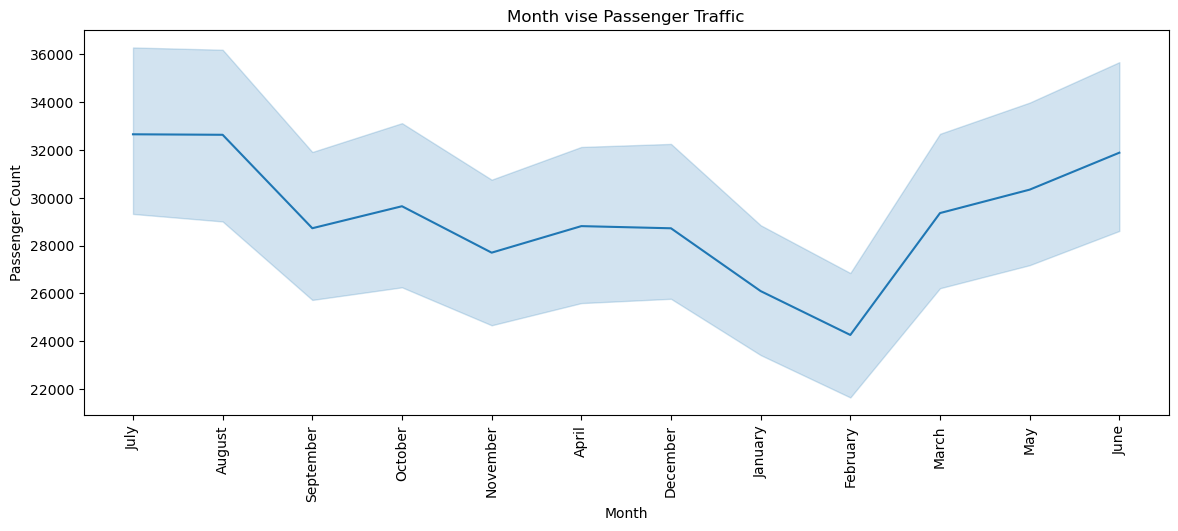

In [62]:
plt.figure(figsize=(14,5))
sb.lineplot(x=df.Month,y=df.Passenger_Count)
plt.title("Month vise Passenger Traffic")
plt.ylabel("Passenger Count")
plt.xticks(rotation=90)
plt.show()


# Busy months:-
#### -February had less rush which indicates its least busy travel month.
#### -Traffic starts arising in March and keeps on increasing till June and July which are the most busiest months indicating a peak of travel season.

## Trends identified from year-over-year passenger data

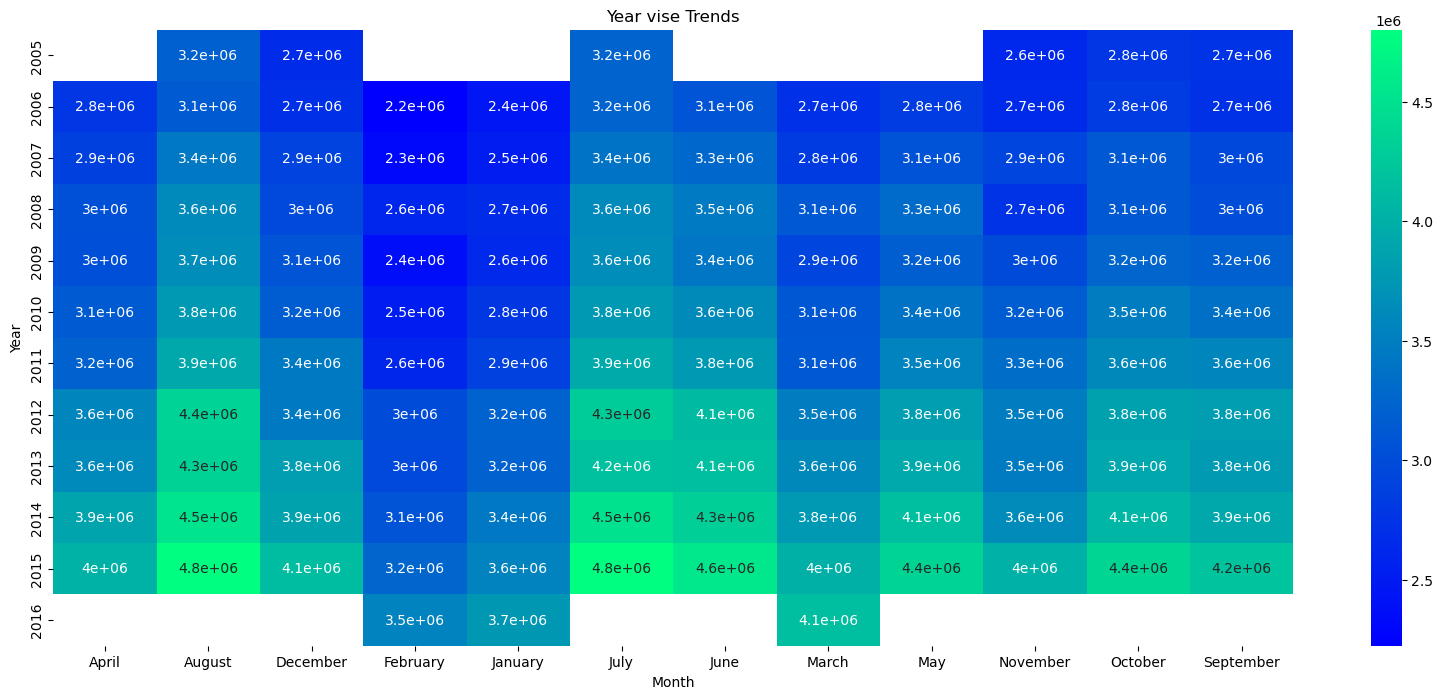

In [63]:
plt.figure(figsize=(20,8))
sb.heatmap(q,annot=True,cmap='winter')
plt.title("Year vise Trends")
plt.show()

# Year vise Trends 
#### -From 2005 to 2016 the passenger traffic rapidly increased in the months of July and August showing high usage of Airways in the following months.
#### -Whereas other months like January, February, March showed constant trend of less traffic in the data of past 10 Years.  
#### -In months May, June, September and October passenger traffic hiked in last 4 years. 

# Airline Analysis

### Airlines handling  the highest number of passengers

In [64]:
df.groupby('Operating_Airline')['Passenger_Count'].sum().nlargest()

Operating_Airline
United Airlines      170240913
SkyWest Airlines      35711737
American Airlines     34588714
Virgin America        26934738
Delta Air Lines       26440420
Name: Passenger_Count, dtype: int64

#### -United Airlines have highest traffic which is then followed by Skywest Airlines and American Airlines.

### Airlines handling  the lowest number of passengers

In [65]:
df.groupby('Operating_Airline')['Passenger_Count'].sum().nsmallest()

Operating_Airline
Evergreen International Airlines      4
Boeing Company                       18
Atlas Air, Inc                       68
Ameriflight                         110
Xtra Airways                        146
Name: Passenger_Count, dtype: int64

#### -Evergreen International Airlines has the lowest passenger count which is followed by Boeing Company.

### Passenger traffic distributed among different Airlines

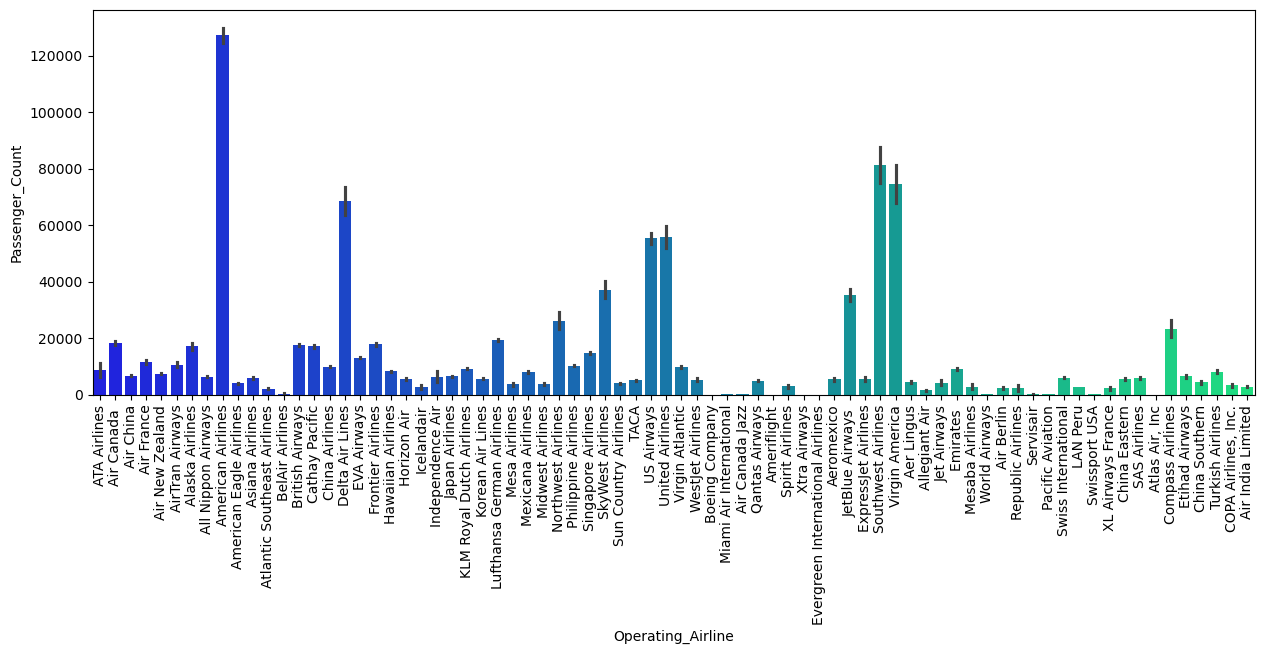

In [66]:
plt.figure(figsize=(15,5))
plt.xticks(rotation=90)
sb.barplot(x=df.Operating_Airline,y=df.Passenger_Count,palette='winter')
plt.show()

# Distribution:- 

#### -United Airlines, American Airlines, and Southwest Airlines have the highest average passenger counts, showing they are the most used airlines.

#### -Airlines like Virgin America, Delta Air Lines, and SkyWest Airlines also see significant passenger volume.

#### -On the other hand, many smaller or less active airlines, like Evergreen, Boeing Company, or Ameriflight, show very low passenger numbers.

# Terminal and Boarding Area Analysis

## Terminals and Boarding areas busiest in terms of passenger traffic


In [67]:
tb = df.groupby(['Terminal','Boarding_Area'])['Passenger_Count'].sum().reset_index().sort_values('Passenger_Count',ascending=False)
tb

,Terminal,Boarding_Area,Passenger_Count
8,Terminal 3,F,138526673
4,Terminal 1,B,67373108
0,International,A,57670570
1,International,G,57613844
5,Terminal 1,C,42271640
7,Terminal 3,E,40886909
6,Terminal 2,D,34060240
3,Terminal 1,A,409316
2,Other,Other,200


## Difference in usage between terminals or boarding areas

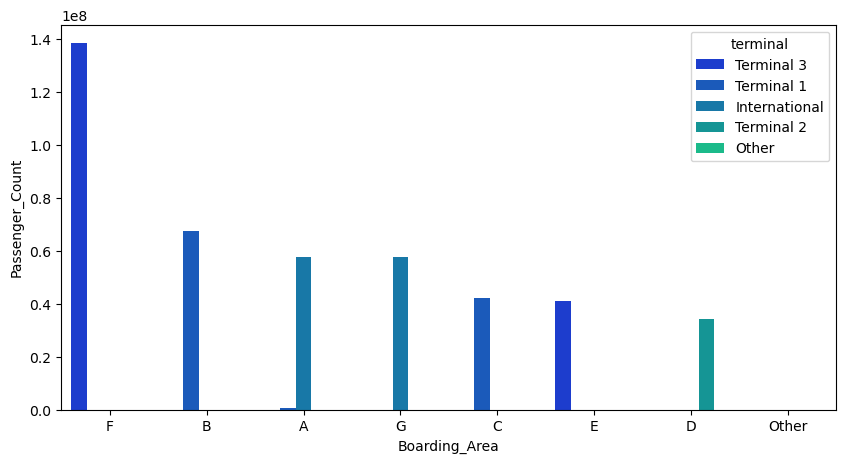

In [69]:
plt.figure(figsize=(10,5))
sb.barplot(x=tb.Boarding_Area,y=tb.Passenger_Count,hue=tb.Terminal,palette='winter')
plt.legend(title='terminal',bbox_to_anchor=(1.0,1.0))
plt.show()

# Terminal Status:-
#### Most of the passenger were boarded from Terminal 3 while others had less rush.
# Boarding Status:-
#### The busiest boarding area is F.

#### -Most passengers traveled through Terminal 3, Area F, making it the busiest spot.
####  -The International Terminal (Areas A and G) also had a lot of passengers, showing many people fly to and from other countries.
#### -Terminal 1 and 2 were busy with domestic flights, while the "Other" area had very few passengers.